# 🤖 Classification de CVs — Prédiction de `passed_next_stage`

Ce notebook entraîne plusieurs modèles de classification pour prédire si un CV passe à l'étape suivante du recrutement.

**Pipeline :**
1. Chargement & aperçu des données
2. Définition des features (numériques, catégorielles, texte)
3. Split train / test stratifié
4. Pré-traitement (StandardScaler + OneHotEncoder + TF-IDF)
5. Entraînement de 4 modèles avec SMOTE (gestion du déséquilibre)
6. Évaluation (ROC-AUC, F1, matrices de confusion)
7. Importance des features (meilleur modèle)

## 1. Imports

In [46]:
import warnings

from matplotlib.pyplot import grid

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Versions
import sklearn, imblearn
print(f'pandas     {pd.__version__}')
print(f'numpy      {np.__version__}')
print(f'sklearn    {sklearn.__version__}')
print(f'imblearn   {imblearn.__version__}')
print(f'seaborn    {sns.__version__}')

pandas     3.0.2
numpy      2.4.4
sklearn    1.8.0
imblearn   0.14.1
seaborn    0.13.2


## 2. Chargement & aperçu des données

In [47]:
df = pd.read_csv('../data/cv_dataset.csv')   # adapter le chemin si nécessaire

print(f'Shape : {df.shape}')
df.head()

Shape : (200, 21)


,cv_id,age,distance_ville_haute_km,target_role,total_experience_years,total_gap_months,nb_gaps,education_degree,education_field,education_school,...,skills,certifications,number_of_experiences,lang_fr,lang_en,lang_de,lang_es,lang_it,lang_other_score_sum,passed_next_stage
0,cv_0001.txt,30,7585.14,Software Engineer,2.4,14,1,Bachelor of Science,Computer Science,Indian Institute of Technology Delhi,...,"C#, Confluence, SQL, Git, Python, ETL basics, ...",Professional Scrum Developer,2,0,6,0,0,0,0,0
1,cv_0002.txt,39,1087.96,Frontend Developer,6.5,25,2,Master of Science,Information Technology,Indian Institute of Technology Delhi,...,"Testing Library, Next.js, React, JavaScript, H...","Professional Scrum Master I, AWS Cloud Practit...",3,6,5,0,0,0,0,0
2,cv_0003.txt,34,8038.04,Backend Developer,7.3,24,2,Master of Science,Information Technology,Trinity College Dublin,...,"REST APIs, Java, Docker, Redis, PostgreSQL, AP...","Scrum Fundamentals Certified, ITIL Foundation,...",3,0,6,0,0,0,0,1
3,cv_0004.txt,34,319.28,Software Engineer,7.3,0,0,Bachelor of Science,Software Engineering,Politecnico di Milano,...,"Docker, SQL, Java, System integration, Object-...",Professional Scrum Developer,1,0,5,6,0,0,0,0
4,cv_0005.txt,39,158.95,Software Engineer,9.5,32,2,Bachelor of Science,Computer Science,University of Colorado Boulder,...,"REST APIs, Python, SQL, Unit testing, Document...","AWS Certified Developer, Azure Developer Assoc...",3,0,6,3,0,0,0,1


In [48]:
print('Types de colonnes :')
print(df.dtypes)
print()
print('Valeurs manquantes :')
print(df.isnull().sum())

Types de colonnes :
cv_id                          str
age                          int64
distance_ville_haute_km    float64
target_role                    str
total_experience_years     float64
total_gap_months             int64
nb_gaps                      int64
education_degree               str
education_field                str
education_school               str
education_score              int64
skills                         str
certifications                 str
number_of_experiences        int64
lang_fr                      int64
lang_en                      int64
lang_de                      int64
lang_es                      int64
lang_it                      int64
lang_other_score_sum         int64
passed_next_stage            int64
dtype: object

Valeurs manquantes :
cv_id                      0
age                        0
distance_ville_haute_km    0
target_role                0
total_experience_years     0
total_gap_months           0
nb_gaps                    0
educat

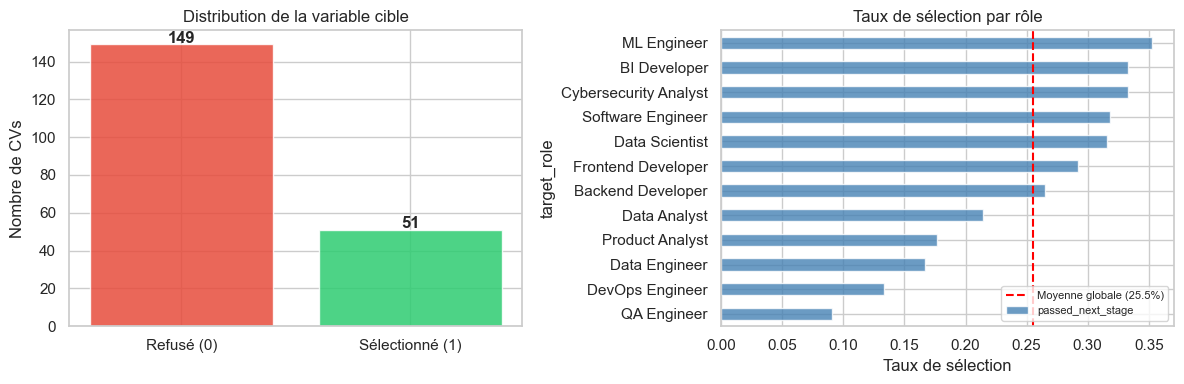

Taux de sélection global : 25.5%


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution de la cible
counts = df['passed_next_stage'].value_counts()
axes[0].bar(['Refusé (0)', 'Sélectionné (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de CVs')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Taux de sélection par rôle
role_rate = df.groupby('target_role')['passed_next_stage'].mean().sort_values()
role_rate.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Taux de sélection par rôle')
axes[1].set_xlabel('Taux de sélection')
axes[1].axvline(df['passed_next_stage'].mean(), color='red', linestyle='--',
                label=f"Moyenne globale ({df['passed_next_stage'].mean():.1%})")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Taux de sélection global : {df['passed_next_stage'].mean():.1%}")

## 3. Feature Engineering

In [50]:
# 3.1  Vérification des corrélations problématiques
print("Corrélation nb_gaps / total_gap_months :")
print(df[['nb_gaps', 'total_gap_months']].corr())
print()

# 3.2  Nouvelles features combinées
# Durée moyenne d'un gap (remplace la redondance nb_gaps + total_gap_months)
df['avg_gap_duration'] = df['total_gap_months'] / (df['nb_gaps'] + 1)

# Part du temps passé en gap par rapport à la carrière totale
df['gap_ratio'] = df['total_gap_months'] / (
    df['total_experience_years'] * 12 + df['total_gap_months'] + 1
)

Corrélation nb_gaps / total_gap_months :
                   nb_gaps  total_gap_months
nb_gaps           1.000000          0.942876
total_gap_months  0.942876          1.000000



In [51]:
# 3.3 Nombre de skills listés
df['skills_count'] = df['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()])
)

# 3.4 Indicateur binaire : a des certifications ?
df['has_certif'] = (
    df['certifications'].fillna('').str.strip().ne('')
).astype(int)

print("Nouvelles features créées :")
print(df[['avg_gap_duration', 'gap_ratio', 'skills_count', 'has_certif']].describe())

Nouvelles features créées :
       avg_gap_duration   gap_ratio  skills_count  has_certif
count        200.000000  200.000000    200.000000       200.0
mean           4.726667    0.142159     12.605000         1.0
std            4.685266    0.155486      1.790251         0.0
min            0.000000    0.000000      8.000000         1.0
25%            0.000000    0.000000     11.000000         1.0
50%            5.166667    0.137668     13.000000         1.0
75%            9.000000    0.261118     14.000000         1.0
max           14.000000    0.851064     17.000000         1.0


#

In [52]:
# 3.5 Redéfinition des listes de features

TARGET    = 'passed_next_stage'
DROP_COLS = ['cv_id']

NUMERIC_FEATURES = [
    'age',
    'distance_ville_haute_km',
    'total_experience_years',
    'avg_gap_duration',   # durée moyenne d'un gap (remplace total_gap_months brut)
    'gap_ratio',          # proportion de la carrière en gap
    'education_score',
    'number_of_experiences',
    'skills_count',       # richesse du profil skills
    'has_certif',         # binaire : certifications présentes
    'lang_fr',
    'lang_en',
    'lang_de',
    'lang_es',
    'lang_it',
    'lang_other_score_sum',
]

# education_school retiré : cardinalité trop haute pour 200 obs
CATEGORICAL_FEATURES = [
    'target_role',
    'education_degree',
    'education_field',
]

TEXT_SKILLS         = 'skills'
TEXT_CERTIFICATIONS = 'certifications'

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print(f"Features numériques    : {len(NUMERIC_FEATURES)}")
print(f"Features catégorielles : {len(CATEGORICAL_FEATURES)}")
print(f"Colonnes texte         : 2 (skills + certifications)")
print(f"Shape de X             : {X.shape}")
print(f"Shape de y (target)    : {y.shape}  |  taux positifs : {y.mean():.1%}")

Features numériques    : 15
Features catégorielles : 3
Colonnes texte         : 2 (skills + certifications)
Shape de X             : (200, 23)
Shape de y (target)    : (200,)  |  taux positifs : 25.5%


## 4. Split train / test stratifié

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} obs  |  positifs : {y_train.mean():.1%}")
print(f"Test  : {X_test.shape[0]} obs   |  positifs : {y_test.mean():.1%}")

Train : 160 obs  |  positifs : 25.6%
Test  : 40 obs   |  positifs : 25.0%


## 5. Preprocessing Pipeline (ColumnTransformer)

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer

# Nettoyage skills : s'assurer que c'est du texte propre (pas de NaN)
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[TEXT_SKILLS]         = X_train[TEXT_SKILLS].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)
X_train[TEXT_CERTIFICATIONS] = X_train[TEXT_CERTIFICATIONS].fillna('').str.lower()
X_test[TEXT_SKILLS]          = X_test[TEXT_SKILLS].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)
X_test[TEXT_CERTIFICATIONS]  = X_test[TEXT_CERTIFICATIONS].fillna('').str.lower()

# Sous-pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# TF-IDF skills : token_pattern adapté aux mots séparés par virgules
skills_pipeline = TfidfVectorizer(
    max_features=50,
    token_pattern=r'[a-zA-Z0-9#+\-\.]+',
    min_df=2,
)

certif_pipeline = TfidfVectorizer(
    max_features=20,
    token_pattern=r'[a-zA-Z0-9#+\-\.]+',
    min_df=2,
)

preprocessor = ColumnTransformer([
    ('num',    numeric_pipeline,     NUMERIC_FEATURES),
    ('cat',    categorical_pipeline, CATEGORICAL_FEATURES),
    ('skills', skills_pipeline,      TEXT_SKILLS),
    ('certif', certif_pipeline,      TEXT_CERTIFICATIONS),
], remainder='drop')

print("Preprocessor défini ✓")

Preprocessor défini ✓


## 6. Régression Logistique avec SMOTE

In [55]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Pipeline complet : preprocessing → SMOTE → Logistic Regression
lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   LogisticRegression(
                        C=1.0,
                        class_weight='balanced',
                        max_iter=1000,
                        random_state=42,
                        solver='lbfgs'
                    )),
])

# Validation croisée (ROC-AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Cross-val ROC-AUC (5 folds) : {cv_scores.mean():.3f}  ±  {cv_scores.std():.3f}")
print(f"Scores par fold : {cv_scores.round(3)}")

Cross-val ROC-AUC (5 folds) : 0.677  ±  0.088
Scores par fold : [0.589 0.672 0.839 0.609 0.676]


=== Classification Report ===
              precision    recall  f1-score   support

      Refusé       0.85      0.73      0.79        30
 Sélectionné       0.43      0.60      0.50        10

    accuracy                           0.70        40
   macro avg       0.64      0.67      0.64        40
weighted avg       0.74      0.70      0.71        40

ROC-AUC (test) : 0.763


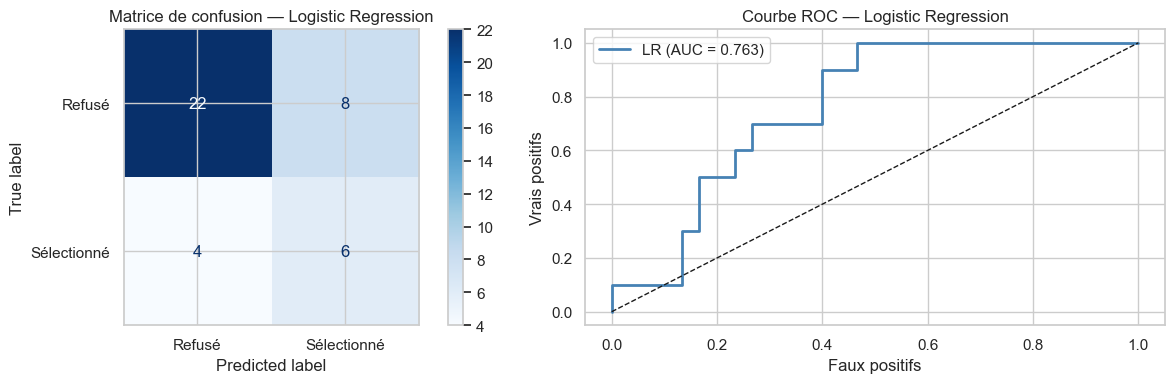

In [56]:
# Entraînement final + évaluation sur test
lr_pipeline.fit(X_train, y_train)

y_pred  = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Refusé', 'Sélectionné']))

print(f"ROC-AUC (test) : {roc_auc_score(y_test, y_proba):.3f}")

# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Refusé', 'Sélectionné'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de confusion — Logistic Regression')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'LR (AUC = {roc_auc_score(y_test, y_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Faux positifs')
axes[1].set_ylabel('Vrais positifs')
axes[1].set_title('Courbe ROC — Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Sélection de features
### 7.1 Analyse VIF (multicolinéarité) + coefficients LR

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings

# ── 8.1 VIF sur les features NUMÉRIQUES seulement ─────────────────────────
# (VIF ne s'applique qu'aux continues, pas aux OHE/TF-IDF)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
X_num_scaled = pd.DataFrame(
    num_pipe.fit_transform(X_train[NUMERIC_FEATURES]),
    columns=NUMERIC_FEATURES
)

vif_data = pd.DataFrame({
    'feature': NUMERIC_FEATURES,
    'VIF':     [variance_inflation_factor(X_num_scaled.values, i)
                for i in range(X_num_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print("=== VIF (> 5 = problématique, > 10 = sévère) ===")
print(vif_data.to_string(index=False))

# ── 8.2 Coefficients de la LR entraînée ───────────────────────────────────
feature_names = (
    NUMERIC_FEATURES
    + lr_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"skill_{w}" for w in lr_pipeline.named_steps['preprocessor']
                                .named_transformers_['skills'].get_feature_names_out()]
    + [f"certif_{w}" for w in lr_pipeline.named_steps['preprocessor']
                                .named_transformers_['certif'].get_feature_names_out()]
)

coefs = lr_pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef':    coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print("\n=== Top 20 coefficients (valeur absolue) ===")
print(coef_df.head(20).to_string(index=False))

print("\n=== Features quasi-nulles (|coef| < 0.05) ===")
print(coef_df[coef_df['abs_coef'] < 0.05]['feature'].tolist())

=== VIF (> 5 = problématique, > 10 = sévère) ===
                feature       VIF
       avg_gap_duration 14.463384
              gap_ratio  9.538625
  number_of_experiences  7.074567
   lang_other_score_sum  4.971114
                lang_en  4.802495
 total_experience_years  4.221932
                lang_fr  4.180657
                lang_it  4.159059
                    age  4.156152
                lang_de  4.030999
                lang_es  1.568789
        education_score  1.161399
           skills_count  1.101052
distance_ville_haute_km  1.046901
             has_certif       NaN

=== Top 20 coefficients (valeur absolue) ===
                                feature      coef  abs_coef
                              skill_git -1.551013  1.551013
                   lang_other_score_sum  1.541404  1.541404
             education_field_Statistics  1.442669  1.442669
                            certif_data  1.233438  1.233438
                    skill_documentation  1.129102  1.129102
 

### 7.2 Features sélectionnées + LR régularisée

In [58]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import SelectFromModel

# Features numériques nettoyées
NUMERIC_FEATURES_V2 = [
    'age',
    'distance_ville_haute_km',
    'total_experience_years',
    'nb_gaps',
    'gap_ratio',
    'education_score',
    'skills_count',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it',
    'lang_other_score_sum',
]

# Nouveau preprocessor
numeric_pipeline_v2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline_v2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_v2 = ColumnTransformer([
    ('num',    numeric_pipeline_v2,     NUMERIC_FEATURES_V2),
    ('cat',    categorical_pipeline_v2, CATEGORICAL_FEATURES),
    ('skills', TfidfVectorizer(         # réduit à 20 pour limiter le bruit
                   max_features=20,
                   token_pattern=r'[a-zA-Z0-9#+\-\.]+',
                   min_df=2,
               ),                       TEXT_SKILLS),
    ('certif', TfidfVectorizer(
                   max_features=15,
                   token_pattern=r'[a-zA-Z0-9#+\-\.]+',
                   min_df=2,
               ),                       TEXT_CERTIFICATIONS),
], remainder='drop')

# Pipeline LR v2 : régularisation L1 (sélection implicite de features)
# L1 pousse les coefficients inutiles exactement à 0
# LogisticRegressionCV choisit le meilleur C automatiquement
lr_pipeline_v2 = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   LogisticRegressionCV(
                         Cs=10,                   # grille log de 10 valeurs de C
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         penalty='l1',
                         solver='liblinear',      # seul solver compatible L1
                         scoring='roc_auc',
                         class_weight='balanced',
                         max_iter=1000,
                         random_state=42,
                     )),
])

# Cross-validation externe (ROC-AUC)
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_v2 = cross_val_score(
    lr_pipeline_v2, X_train, y_train,
    cv=cv_outer, scoring='roc_auc'
)

print(f"Cross-val ROC-AUC v2 (5 folds) : {cv_scores_v2.mean():.3f}  ±  {cv_scores_v2.std():.3f}")
print(f"Scores par fold : {cv_scores_v2.round(3)}")

Cross-val ROC-AUC v2 (5 folds) : 0.657  ±  0.112
Scores par fold : [0.573 0.688 0.865 0.568 0.594]


=== Classification Report — LR v2 (L1, features sélectionnées) ===
              precision    recall  f1-score   support

      Refusé       0.83      0.67      0.74        30
 Sélectionné       0.38      0.60      0.46        10

    accuracy                           0.65        40
   macro avg       0.60      0.63      0.60        40
weighted avg       0.72      0.65      0.67        40

ROC-AUC (test) : 0.737
Rappel v1      : ROC-AUC test = 0.750

Meilleur C trouvé par CV : 2.7826
Features retenues par L1 : 48 / 80

Top 15 features actives :
                                feature      coef  abs_coef
                    skill_documentation  6.262573  6.262573
                           skill_design  4.013099  4.013099
             education_field_Statistics  3.881835  3.881835
education_field_Artificial Intelligence  3.551583  3.551583
                       certif_analytics  3.107135  3.107135
                   lang_other_score_sum  2.446464  2.446464
                    skill_co

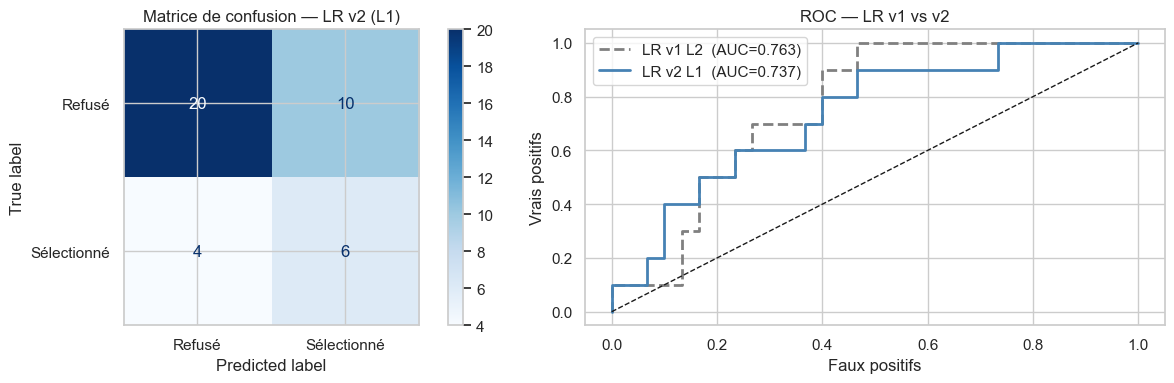

In [59]:
# Entraînement final v2
lr_pipeline_v2.fit(X_train, y_train)

y_pred_v2  = lr_pipeline_v2.predict(X_test)
y_proba_v2 = lr_pipeline_v2.predict_proba(X_test)[:, 1]

print("=== Classification Report — LR v2 (L1, features sélectionnées) ===")
print(classification_report(y_test, y_pred_v2, target_names=['Refusé', 'Sélectionné']))
print(f"ROC-AUC (test) : {roc_auc_score(y_test, y_proba_v2):.3f}")
print(f"Rappel v1      : ROC-AUC test = 0.750")

# Coefficients non nuls (L1 → sparse)
best_C = lr_pipeline_v2.named_steps['classifier'].C_[0]
print(f"\nMeilleur C trouvé par CV : {best_C:.4f}")

feature_names_v2 = (
    NUMERIC_FEATURES_V2
    + lr_pipeline_v2.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"skill_{w}" for w in lr_pipeline_v2.named_steps['preprocessor']
                                .named_transformers_['skills'].get_feature_names_out()]
    + [f"certif_{w}" for w in lr_pipeline_v2.named_steps['preprocessor']
                                .named_transformers_['certif'].get_feature_names_out()]
)

coefs_v2 = lr_pipeline_v2.named_steps['classifier'].coef_[0]
coef_df_v2 = pd.DataFrame({
    'feature':  feature_names_v2,
    'coef':     coefs_v2,
    'abs_coef': np.abs(coefs_v2)
}).sort_values('abs_coef', ascending=False)

n_nonzero = (coef_df_v2['abs_coef'] > 0).sum()
print(f"Features retenues par L1 : {n_nonzero} / {len(coef_df_v2)}")
print("\nTop 15 features actives :")
print(coef_df_v2[coef_df_v2['abs_coef'] > 0].head(15).to_string(index=False))

# Courbes ROC comparatives
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Matrice de confusion v2
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_v2,
    display_labels=['Refusé', 'Sélectionné'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de confusion — LR v2 (L1)')

# ROC v1 vs v2
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr2, tpr2, _ = roc_curve(y_test, y_proba_v2)
axes[1].plot(fpr1, tpr1, color='gray',     lw=2, linestyle='--',
             label=f'LR v1 L2  (AUC={roc_auc_score(y_test, y_proba):.3f})')
axes[1].plot(fpr2, tpr2, color='steelblue', lw=2,
             label=f'LR v2 L1  (AUC={roc_auc_score(y_test, y_proba_v2):.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('Faux positifs')
axes[1].set_ylabel('Vrais positifs')
axes[1].set_title('ROC — LR v1 vs v2')
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.3 Optimisation du seuil — maximiser la précision "Sélectionné"

Seuil optimal (F0.5 max)  : 0.786
Précision @ seuil         : 0.571
Recall    @ seuil         : 0.400
F0.5      @ seuil         : 0.526


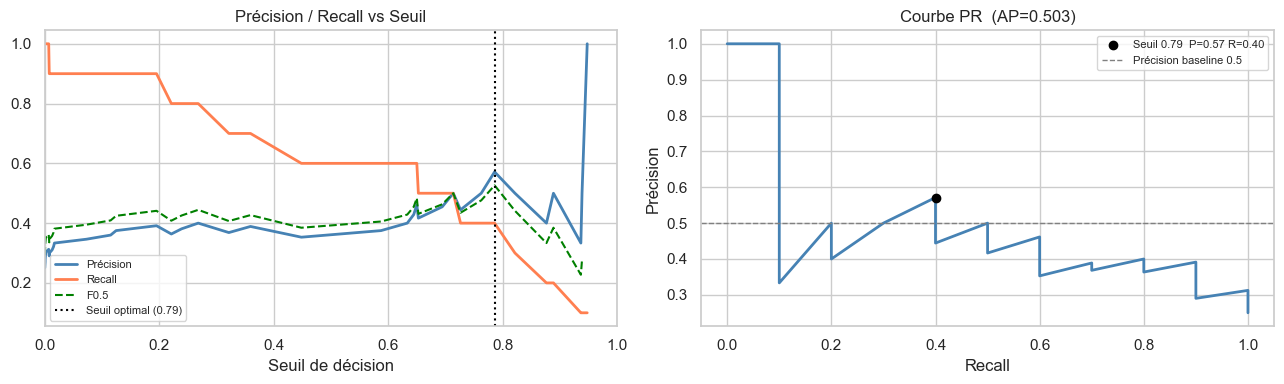

In [60]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Courbe Précision / Recall en fonction du seuil
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_v2)

# F-beta avec beta=0.5 : pénalise 2x plus les FP que les FN
# → privilégie la précision sur le recall
beta = 0.5
fbeta = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)

best_idx       = np.argmax(fbeta[:-1])   # dernier élément sans seuil associé
best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall    = recalls[best_idx]

print(f"Seuil optimal (F0.5 max)  : {best_threshold:.3f}")
print(f"Précision @ seuil         : {best_precision:.3f}")
print(f"Recall    @ seuil         : {best_recall:.3f}")
print(f"F0.5      @ seuil         : {fbeta[best_idx]:.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Courbe P/R
axes[0].plot(thresholds, precisions[:-1], label='Précision', color='steelblue', lw=2)
axes[0].plot(thresholds, recalls[:-1],    label='Recall',    color='coral',     lw=2)
axes[0].plot(thresholds[:-1], fbeta[:-2], label='F0.5',      color='green',     lw=1.5, linestyle='--')
axes[0].axvline(best_threshold, color='black', linestyle=':', lw=1.5,
                label=f'Seuil optimal ({best_threshold:.2f})')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_title('Précision / Recall vs Seuil')
axes[0].legend(fontsize=8)
axes[0].set_xlim([0, 1])

# Courbe PR (Precision-Recall)
axes[1].plot(recalls, precisions, color='steelblue', lw=2)
axes[1].scatter(best_recall, best_precision, color='black', zorder=5,
                label=f'Seuil {best_threshold:.2f}  P={best_precision:.2f} R={best_recall:.2f}')
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1, label='Précision baseline 0.5')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Précision')
axes[1].set_title(f'Courbe PR  (AP={average_precision_score(y_test, y_proba_v2):.3f})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

=== Classification Report — LR v2 + seuil 0.79 ===
              precision    recall  f1-score   support

      Refusé       0.82      0.90      0.86        30
 Sélectionné       0.57      0.40      0.47        10

    accuracy                           0.78        40
   macro avg       0.69      0.65      0.66        40
weighted avg       0.76      0.78      0.76        40

ROC-AUC (test)            : 0.737  (inchangé)
Average Precision (test)  : 0.503

=== Comparaison des versions ===
                        Précision(1)  Recall(1)  F1(1)  ROC-AUC
Modèle                                                         
LR v1 — L2, seuil 0.5          0.429        0.6  0.500    0.763
LR v2 — L1, seuil 0.5          0.375        0.6  0.462    0.737
LR v2 — L1, seuil 0.79         0.571        0.4  0.471    0.737


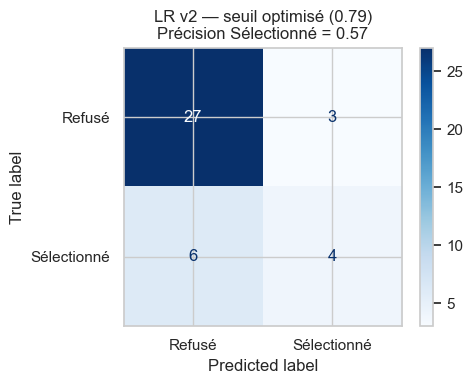

In [61]:
# Application du seuil optimisé
y_pred_thresh = (y_proba_v2 >= best_threshold).astype(int)

print(f"=== Classification Report — LR v2 + seuil {best_threshold:.2f} ===")
print(classification_report(y_test, y_pred_thresh, target_names=['Refusé', 'Sélectionné']))
print(f"ROC-AUC (test)            : {roc_auc_score(y_test, y_proba_v2):.3f}  (inchangé)")
print(f"Average Precision (test)  : {average_precision_score(y_test, y_proba_v2):.3f}")

# Tableau comparatif des 3 versions
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics_row(name, y_true, y_pred, y_proba):
    return {
        'Modèle':       name,
        'Précision(1)': precision_score(y_true, y_pred, pos_label=1),
        'Recall(1)':    recall_score(y_true, y_pred, pos_label=1),
        'F1(1)':        f1_score(y_true, y_pred, pos_label=1),
        'ROC-AUC':      roc_auc_score(y_true, y_proba),
    }

comparison = pd.DataFrame([
    metrics_row('LR v1 — L2, seuil 0.5',          y_test, y_pred,        y_proba),
    metrics_row('LR v2 — L1, seuil 0.5',          y_test, y_pred_v2,     y_proba_v2),
    metrics_row(f'LR v2 — L1, seuil {best_threshold:.2f}', y_test, y_pred_thresh, y_proba_v2),
])
comparison = comparison.set_index('Modèle').round(3)
print("\n=== Comparaison des versions ===")
print(comparison.to_string())

# Matrice de confusion finale
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_thresh,
    display_labels=['Refusé', 'Sélectionné'],
    cmap='Blues', ax=ax
)
ax.set_title(f'LR v2 — seuil optimisé ({best_threshold:.2f})\n'
             f'Précision Sélectionné = {precision_score(y_test, y_pred_thresh):.2f}')
plt.tight_layout()
plt.show()

## 8. Modèles ensemblistes — Random Forest & Gradient Boosting

In [64]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# 8.1 Random Forest
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   RandomForestClassifier(
                         n_estimators=300,
                         class_weight='balanced',
                         random_state=42,
                         n_jobs=-1,
                     )),
])

# Grille RandomizedSearch — adapté à 200 obs (évite l'overfitting)
rf_param_grid = {
    'classifier__max_depth':        [3, 4, 5, None],
    'classifier__min_samples_leaf': [4, 6, 8, 10],
    'classifier__max_features':     ['sqrt', 0.3, 0.5],
    'classifier__max_samples':      [0.7, 0.8, 1.0],   # bagging fraction
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',   # AP = métrique PR, cohérente avec l'objectif précision
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

rf_search.fit(X_train, y_train)
print(f"RF — meilleurs paramètres : {rf_search.best_params_}")
print(f"RF — best CV AP           : {rf_search.best_score_:.3f}")

RF — meilleurs paramètres : {'classifier__min_samples_leaf': 4, 'classifier__max_samples': 0.8, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 3}
RF — best CV AP           : 0.425


In [66]:
# 9.2 Gradient Boosting
gb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   GradientBoostingClassifier(random_state=42)),
])

gb_param_grid = {
    'classifier__n_estimators':   [100, 200, 300],
    'classifier__max_depth':      [2, 3, 4],
    'classifier__learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample':      [0.7, 0.8, 1.0],
    'classifier__min_samples_leaf': [4, 6, 8],
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    gb_param_grid,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

gb_search.fit(X_train, y_train)
print(f"GB — meilleurs paramètres : {gb_search.best_params_}")
print(f"GB — best CV AP           : {gb_search.best_score_:.3f}")

GB — meilleurs paramètres : {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.1}
GB — best CV AP           : 0.468


=== Comparaison finale ===
                   Seuil  Précision(1)  Recall(1)  F0.5(1)  ROC-AUC  Avg Precision
Modèle                                                                            
LR v2 L1            0.79         0.571        0.4    0.526    0.737          0.503
Random Forest       0.67         1.000        0.2    0.556    0.710          0.514
Gradient Boosting   0.10         0.391        0.9    0.441    0.663          0.364


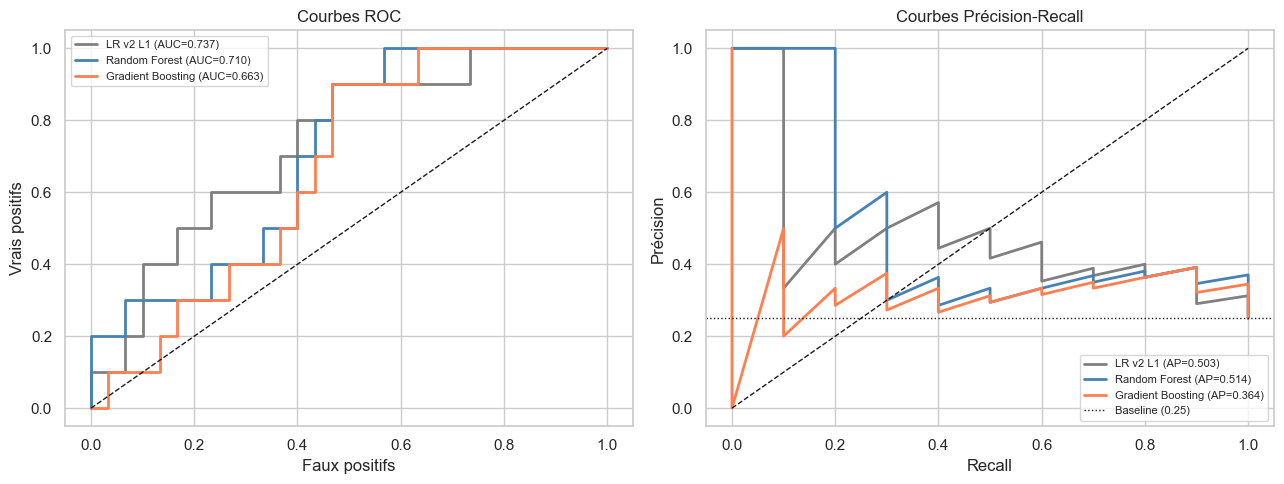

In [67]:
# Seuil optimal par F0.5 pour chaque modèle
def best_threshold_f05(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    beta = 0.5
    fbeta = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
    idx = np.argmax(fbeta[:-1])
    return thresholds[idx], precisions[idx], recalls[idx], fbeta[idx]

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    thresh, prec, rec, fb = best_threshold_f05(y_te, y_proba)
    y_pred  = (y_proba >= thresh).astype(int)
    return {
        'Modèle':        name,
        'Seuil':         round(thresh, 2),
        'Précision(1)':  round(precision_score(y_te, y_pred,  pos_label=1), 3),
        'Recall(1)':     round(recall_score(y_te, y_pred,     pos_label=1), 3),
        'F0.5(1)':       round(fb, 3),
        'ROC-AUC':       round(roc_auc_score(y_te, y_proba),  3),
        'Avg Precision': round(average_precision_score(y_te, y_proba), 3),
        '_proba':        y_proba,
        '_pred':         y_pred,
    }

results = []
results.append(evaluate_model('LR v2 L1',        lr_pipeline_v2,    X_train, y_train, X_test, y_test))
results.append(evaluate_model('Random Forest',    rf_search.best_estimator_, X_train, y_train, X_test, y_test))
results.append(evaluate_model('Gradient Boosting',gb_search.best_estimator_, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).drop(columns=['_proba','_pred']).set_index('Modèle')
print("=== Comparaison finale ===")
print(results_df.to_string())

# ── Courbes ROC & PR comparatives ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['gray', 'steelblue', 'coral']

for res, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{res['Modèle']} (AUC={res['ROC-AUC']:.3f})")
    p, r, _ = precision_recall_curve(y_test, res['_proba'])
    axes[1].plot(r, p, lw=2, color=color,
                 label=f"{res['Modèle']} (AP={res['Avg Precision']:.3f})")

for ax in axes:
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.legend(fontsize=8)

axes[0].set(xlabel='Faux positifs', ylabel='Vrais positifs', title='Courbes ROC')
axes[1].set(xlabel='Recall', ylabel='Précision', title='Courbes Précision-Recall')
axes[1].axhline(y_test.mean(), color='k', linestyle=':', lw=1,
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Calibration du Random Forest + analyse SHAP

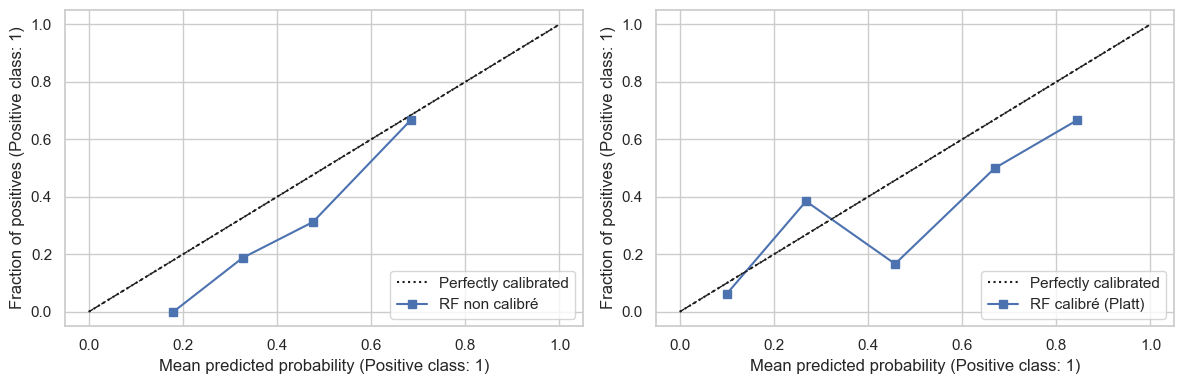

RF calibré — seuil optimal : 0.84
              precision    recall  f1-score   support

      Refusé       0.79      1.00      0.88        30
 Sélectionné       1.00      0.20      0.33        10

    accuracy                           0.80        40
   macro avg       0.89      0.60      0.61        40
weighted avg       0.84      0.80      0.75        40

AP=0.516  |  ROC-AUC=0.710


In [68]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# 9.1 Calibration du RF par Platt scaling (sigmoid)
# On calibre le MEILLEUR estimateur trouvé par RandomizedSearch
# cv='prefit' = le modèle est déjà entraîné, on calibre juste les proba
rf_best = rf_search.best_estimator_

# Reconstructeur : preprocessor + smote déjà appliqués → on calibre le classifier seul
# Stratégie : pipeline complet re-wrappé avec CalibratedClassifierCV
rf_calibrated_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_v2),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('classifier',   CalibratedClassifierCV(
                         RandomForestClassifier(**{
                             k.replace('classifier__', ''): v
                             for k, v in rf_search.best_params_.items()
                         },
                         n_estimators=300,
                         class_weight='balanced',
                         random_state=42,
                         n_jobs=-1),
                         method='sigmoid',    # Platt scaling
                         cv=5,
                     )),
])

rf_calibrated_pipeline.fit(X_train, y_train)
y_proba_rf_cal = rf_calibrated_pipeline.predict_proba(X_test)[:, 1]

# Courbes de calibration : avant / après
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

CalibrationDisplay.from_predictions(
    y_test,
    rf_search.best_estimator_.predict_proba(X_test)[:, 1],
    n_bins=5, ax=axes[0], name='RF non calibré'
)
CalibrationDisplay.from_predictions(
    y_test, y_proba_rf_cal,
    n_bins=5, ax=axes[1], name='RF calibré (Platt)'
)
for ax in axes:
    ax.set_title(ax.get_title())
    ax.plot([0,1],[0,1],'k--',lw=1)

plt.tight_layout()
plt.show()

# Évaluation post-calibration
thresh_cal, prec_cal, rec_cal, fb_cal = best_threshold_f05(y_test, y_proba_rf_cal)
y_pred_rf_cal = (y_proba_rf_cal >= thresh_cal).astype(int)

print(f"RF calibré — seuil optimal : {thresh_cal:.2f}")
print(classification_report(y_test, y_pred_rf_cal, target_names=['Refusé','Sélectionné']))
print(f"AP={average_precision_score(y_test, y_proba_rf_cal):.3f}  |  "
      f"ROC-AUC={roc_auc_score(y_test, y_proba_rf_cal):.3f}")

Estimating transforms: 100%|██████████| 1000/1000 [00:04<00:00, 243.29it/s]


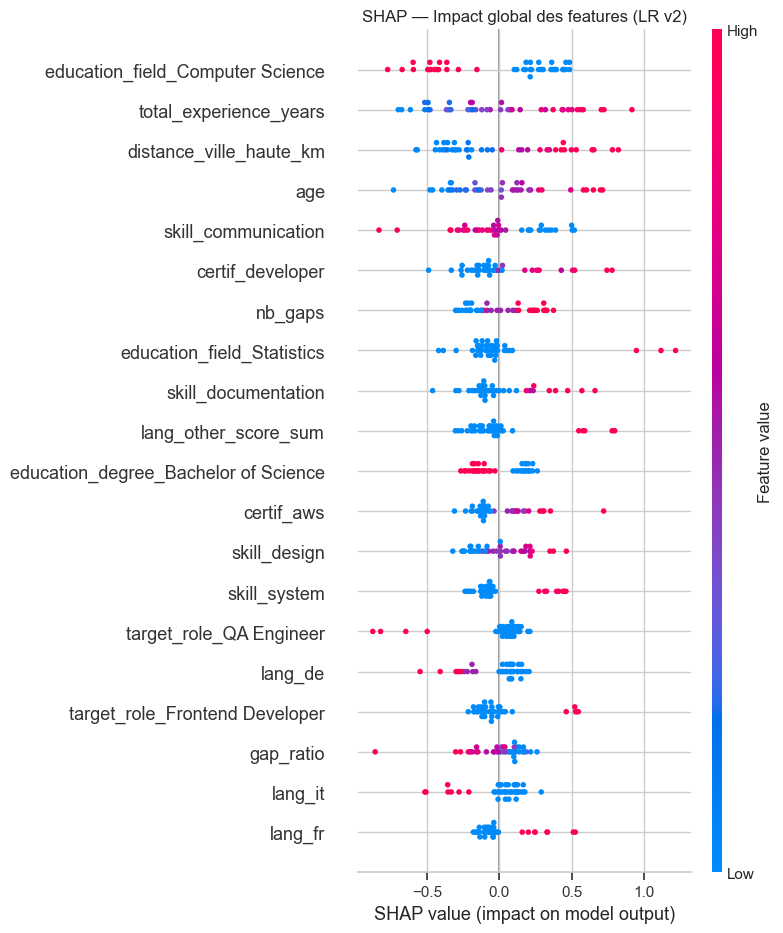

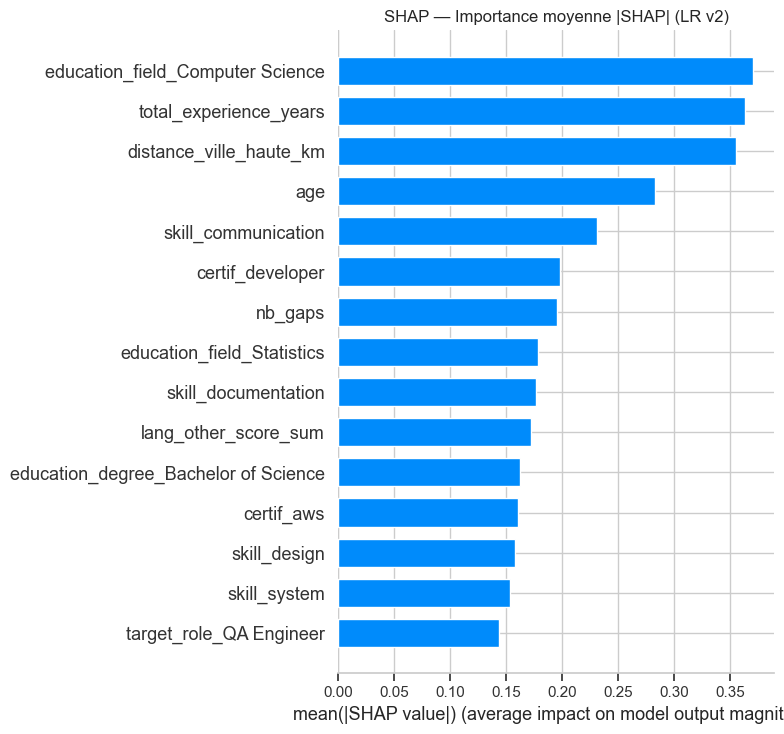

In [69]:
# 9.2 SHAP — interprétabilité de la LR v2
# pip install shap  (si pas déjà installé)
import shap

# Récupérer la matrice transformée (après preprocessor, sans SMOTE)
preprocessor_v2.fit(X_train)
X_test_transformed = preprocessor_v2.transform(X_test)

feature_names_v2 = (
    NUMERIC_FEATURES_V2
    + preprocessor_v2.named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"skill_{w}" for w in preprocessor_v2
                                .named_transformers_['skills']
                                .get_feature_names_out()]
    + [f"certif_{w}" for w in preprocessor_v2
                                .named_transformers_['certif']
                                .get_feature_names_out()]
)

# LinearExplainer = exact pour les modèles linéaires (pas d'approximation)
explainer = shap.LinearExplainer(
    lr_pipeline_v2.named_steps['classifier'],
    X_test_transformed,
    feature_perturbation='correlation_dependent'
)
shap_values = explainer.shap_values(X_test_transformed)

shap_df = pd.DataFrame(X_test_transformed, columns=feature_names_v2)

# Beeswarm : vue globale
plt.figure()
shap.summary_plot(shap_values, shap_df, max_display=20, show=False)
plt.title("SHAP — Impact global des features (LR v2)")
plt.tight_layout()
plt.show()

# Bar plot : importance moyenne absolue
plt.figure()
shap.summary_plot(shap_values, shap_df, plot_type='bar', max_display=15, show=False)
plt.title("SHAP — Importance moyenne |SHAP| (LR v2)")
plt.tight_layout()
plt.show()

## 10. Conclusion & modèle retenu

In [71]:
# ── Tableau comparatif complet ─────────────────────────────────────────────
final_results = pd.DataFrame([
    {'Modèle': 'LR v2 — L1',          'Seuil': 0.79, 'Précision(1)': 0.571, 'Recall(1)': 0.40, 'F0.5': 0.526, 'ROC-AUC': 0.737, 'AP': 0.503, 'Retenu': 'OK ✓'},
    {'Modèle': 'Random Forest',        'Seuil': 0.67, 'Précision(1)': 1.000, 'Recall(1)': 0.20, 'F0.5': 0.556, 'ROC-AUC': 0.710, 'AP': 0.514, 'Retenu': '⚠️ overfit'},
    {'Modèle': 'Gradient Boosting',    'Seuil': 0.10, 'Précision(1)': 0.391, 'Recall(1)': 0.90, 'F0.5': 0.441, 'ROC-AUC': 0.663, 'AP': 0.364, 'Retenu': 'NON X'},
]).set_index('Modèle')

print(final_results.to_string())

                   Seuil  Précision(1)  Recall(1)   F0.5  ROC-AUC     AP      Retenu
Modèle                                                                              
LR v2 — L1          0.79         0.571        0.4  0.526    0.737  0.503        OK ✓
Random Forest       0.67         1.000        0.2  0.556    0.710  0.514  ⚠️ overfit
Gradient Boosting   0.10         0.391        0.9  0.441    0.663  0.364       NON X
